In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import tensorflow as tf

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Input Data

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
      Tahun      Kabupaten  Pen_Miskin  Pengangguran  Laju_Pertumbuhan_PDRB  \
0    2017.0          Kobar     13270.0        3213.0                   3.68   
1    2018.0          Kobar     12900.0        4646.0                   3.42   
2    2019.0          Kobar     12760.0        4318.0                   6.67   
3    2020.0          Kobar     11460.0        8136.0                  12.75   
4    2021.0          Kobar     12290.0        7850.0                   4.36   
5    2022.0          Kobar     12440.0        7535.0                   4.75   
6    2023.0          Kobar     13440.0        6244.0                   4.90   
7    2024.0          Kobar     13430.0        6459.0                   2.92   
8    2025.0          Kobar     14180.0        6546.0                   4.59   
9    2017.0          Kotim     27700.0       10052.0                   5.56   


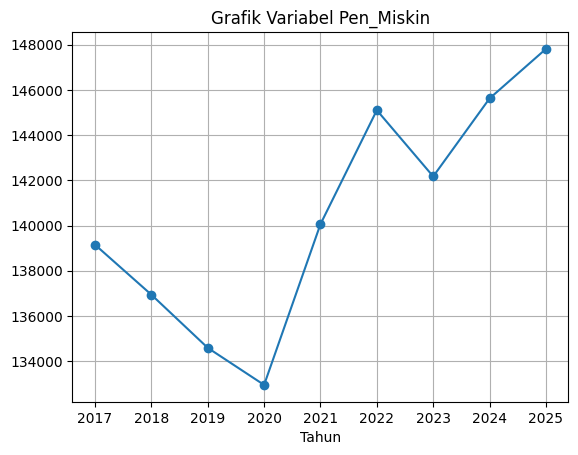

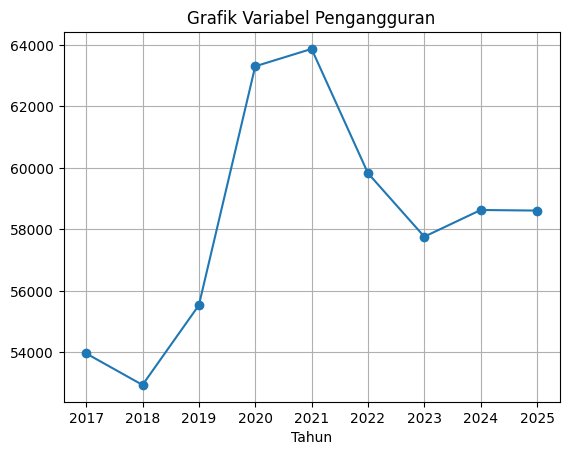

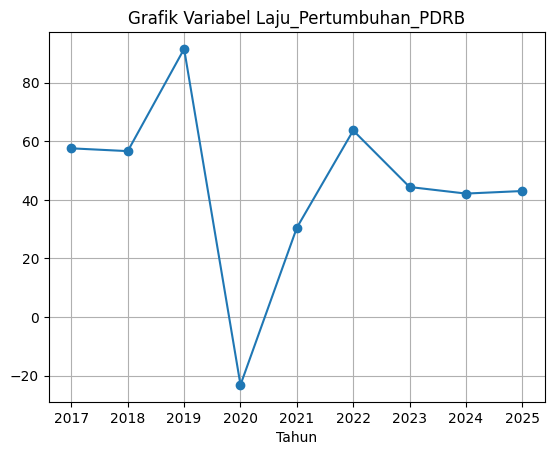

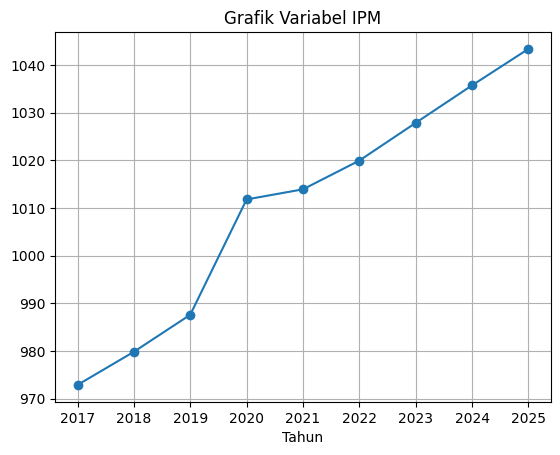

In [58]:
drive.mount('/content/gdrive')
data = pd.read_csv('/content/gdrive/My Drive/JST/datakemiskinan.csv')

# Ubah nilai kolom menjadi numerik
data['Pengangguran'] = pd.to_numeric(data['Pengangguran'], errors='coerce')
data['Laju_Pertumbuhan_PDRB'] = pd.to_numeric(data['Laju_Pertumbuhan_PDRB'], errors='coerce')
data['IPM'] = pd.to_numeric(data['IPM'], errors='coerce')
data['Pen_Miskin'] = pd.to_numeric(data['Pen_Miskin'], errors='coerce')

# Drop baris dengan nilai NaN
data.dropna(inplace=True)

print(data)

data_agregat = data.groupby('Tahun').sum(numeric_only=True).reset_index()

variabel = data_agregat.columns.drop('Tahun')

for var in variabel:
    plt.figure()
    plt.plot(data_agregat['Tahun'], data_agregat[var], marker='o')

    plt.title(f'Grafik Variabel {var}')
    plt.xlabel('Tahun')
    plt.grid()

    plt.show()

# Menentukan Variabel

In [45]:
X = data[['Pengangguran', 'Laju_Pertumbuhan_PDRB', 'IPM']]
y = data['Pen_Miskin']

kabupaten = data['Kabupaten']
tahun = data['Tahun']

# Normalisasi Data

In [46]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Mengubah hasil normalisasi menjadi DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
y_scaled_df = pd.DataFrame(y_scaled, columns=['Pen_Miskin'])

print("Data X setelah normalisasi:")
print(X_scaled_df)
print("\nData Y setelah normalisasi:")
print(y_scaled_df)

Data X setelah normalisasi:
     Pengangguran  Laju_Pertumbuhan_PDRB       IPM
0        0.229773               0.573154  0.354513
1        0.354306               0.566017  0.375297
2        0.325802               0.655229  0.398456
3        0.657600               0.822125  0.463777
4        0.632745               0.591820  0.475653
5        0.605371               0.602525  0.489905
6        0.493178               0.606643  0.521378
7        0.511862               0.552292  0.546912
8        0.519423               0.598133  0.586698
9        0.824107               0.624760  0.239311
10       0.823673               0.595937  0.262470
11       0.814982               0.713149  0.298100
12       1.000000               0.518254  0.418052
13       0.982272               0.498216  0.422209
14       0.888242               0.641230  0.434086
15       0.830364               0.490255  0.466152
16       0.831146               0.549822  0.494656
17       0.829495               0.601702  0.523753
18 

# Split Data

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Bangun Model dan Evaluasi Model

In [48]:
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '42'
hidden_neurons = [10, 35, 50, 70]

results = []
best_model = None
best_rmse = float('inf')
best_history = None
best_neuron = None

for neuron in hidden_neurons:

    print(f"\nTraining model dengan hidden neuron = {neuron}")

    # Bangun model
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(neuron, activation='relu'),
        Dense(1, activation='linear')
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    model.summary()

    # Training
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=200,
        batch_size=16,
        verbose=1
    )

    # Prediksi
    y_pred_scaled = model.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_test_real = scaler_y.inverse_transform(y_test)

    # Evaluasi
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
    mae = mean_absolute_error(y_test_real, y_pred)
    mape = np.mean(np.abs((y_test_real - y_pred) / y_test_real)) * 100

    print(f"RMSE : {rmse}")
    print(f"MAE  : {mae}")
    print(f"MAPE : {mape}")

    # Simpan hasil
    results.append({
        "Hidden_Neuron": neuron,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    })

    # Simpan model terbaik
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model
        best_history = history
        best_neuron = neuron

results_df = pd.DataFrame(results)

print("\n=== PERBANDINGAN MODEL ===")
print(results_df)

best_row = results_df.loc[results_df['RMSE'].idxmin()]

print("\n=== MODEL TERBAIK ===")
print(best_row)

model = best_model


Training model dengan hidden neuron = 10


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 10)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 70)             │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            71 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 351 (1.37 KB)

 Trainable params: 351 (1.37 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0280 - mae: 0.1185 - val_loss: 0.0375 - val_mae: 0.1533
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0247 - mae: 0.1166 - val_loss: 0.0334 - val_mae: 0.1448
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0222 - mae: 0.1102 - val_loss: 0.0302 - val_mae: 0.1345
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0203 - mae: 0.1048 - val_loss: 0.0270 - val_mae: 0.1265
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0186 - mae: 0.1011 - val_loss: 0.0240 - val_mae: 0.1209
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0172 - mae: 0.0980 - val_loss: 0.0217 - val_mae: 0.1157
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0161 - mae: 0.0957 - val_loss: 0.0199 - val_mae: 0.1108
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0153 - mae: 0.0939 - val_loss: 0.0186 - val_mae: 0.1076
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0145 - mae: 

# Prediksi dengan Model Terbaik

In [49]:
y_pred_scaled = best_model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


# Prediksi Seluruh Data

In [50]:
data['Prediksi_Miskin'] = scaler_y.inverse_transform(
    best_model.predict(X_scaled)
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


# Prediksi Tahun Depan

In [51]:
idx = data.groupby('Kabupaten')['Tahun'].idxmax()
data_terakhir = data.loc[idx]

X_next = data_terakhir[['Pengangguran', 'Laju_Pertumbuhan_PDRB', 'IPM']]
X_next_scaled = scaler_X.transform(X_next)

pred_next = scaler_y.inverse_transform(
    best_model.predict(X_next_scaled)
)

pred_next_df = pd.DataFrame({
    'Kabupaten': data_terakhir['Kabupaten'].values,
    'Tahun': (data_terakhir['Tahun'] + 1).values,
    'Prediksi_Miskin': pred_next.flatten()
})

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


# Tren Penurunan per Kabupaten

In [52]:
hasil_tren = []

for kab in data['Kabupaten'].unique():
    data_kab = data[data['Kabupaten'] == kab].sort_values('Tahun')

    awal = data_kab['Prediksi_Miskin'].iloc[0]
    akhir = data_kab['Prediksi_Miskin'].iloc[-1]
    selisih_tahun = data_kab['Tahun'].iloc[-1] - data_kab['Tahun'].iloc[0]

    tren = (akhir - awal) / selisih_tahun
    hasil_tren.append([kab, tren])

tren_df = pd.DataFrame(
    hasil_tren, columns=['Kabupaten', 'Laju_Penurunan']
).sort_values('Laju_Penurunan')

# Hasil

In [53]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)  # menampilkan semua kolom
pd.set_option('display.width', None)        # agar tidak terpotong ke samping

print("\n=== TABEL HASIL PREDIKSI ===")
print(data[['Kabupaten','Tahun','Pen_Miskin','Prediksi_Miskin']])

print("\n=== TABEL TREN PENURUNAN ===")
print(tren_df)

print("\n=== PREDIKSI TAHUN DEPAN ===")
print(pred_next_df)


=== TABEL HASIL PREDIKSI ===
         Kabupaten   Tahun  Pen_Miskin  Prediksi_Miskin
0            Kobar  2017.0     13270.0      9032.460938
1            Kobar  2018.0     12900.0     11319.390625
2            Kobar  2019.0     12760.0     10848.428711
3            Kobar  2020.0     11460.0     18368.148438
4            Kobar  2021.0     12290.0     17641.791016
5            Kobar  2022.0     12440.0     16609.160156
6            Kobar  2023.0     13440.0     13039.872070
7            Kobar  2024.0     13430.0     12925.641602
8            Kobar  2025.0     14180.0     12769.805664
9            Kotim  2017.0     27700.0     24864.464844
10           Kotim  2018.0     28200.0     24811.292969
11           Kotim  2019.0     27380.0     24312.056641
12           Kotim  2020.0     26640.0     27908.007812
13           Kotim  2021.0     27060.0     27390.421875
14           Kotim  2022.0     27560.0     25579.753906
15           Kotim  2023.0     26570.0     23348.039062
16           Kotim

# Grafik Loss

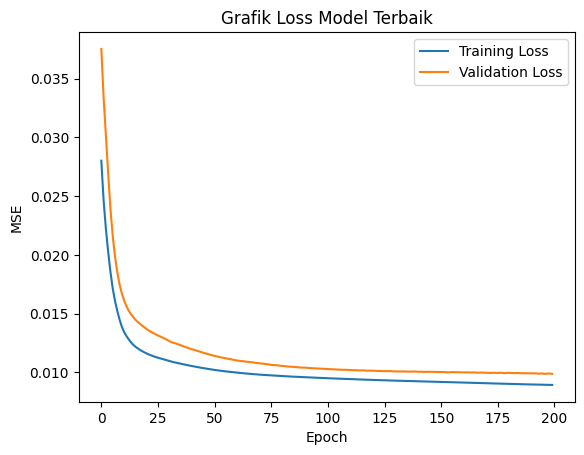

In [59]:
plt.figure()
plt.plot(best_history.history['loss'], label='Training Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Grafik Loss Model Terbaik')
plt.legend()
plt.show()

# Grafik Aktual vs Prediksi

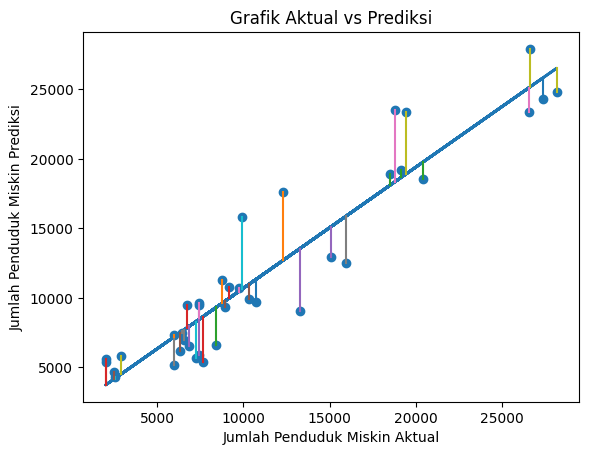

In [55]:
plt.figure()
plt.scatter(y_test_real, y_pred)

m, b = np.polyfit(y_test_real.flatten(), y_pred.flatten(), 1)
reg_line = m * y_test_real + b

# Plot garis regresi
plt.plot(y_test_real, reg_line, linewidth=2)

# Menambahkan garis residual dari garis regresi ke titik
for i in range(len(y_test_real)):
    plt.plot([y_test_real[i], y_test_real[i]],
             [reg_line[i], y_pred[i]])
plt.xlabel("Jumlah Penduduk Miskin Aktual")
plt.ylabel("Jumlah Penduduk Miskin Prediksi")
plt.title("Grafik Aktual vs Prediksi")
plt.show()